In [1]:
import numpy as np
import matplotlib.pyplot as plt

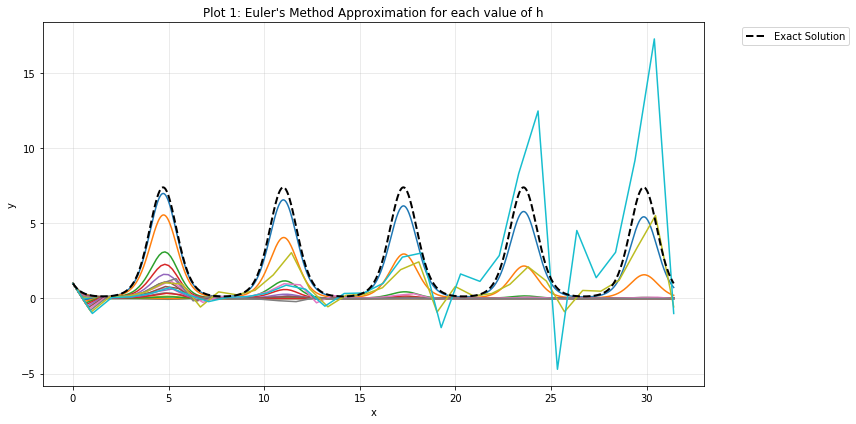

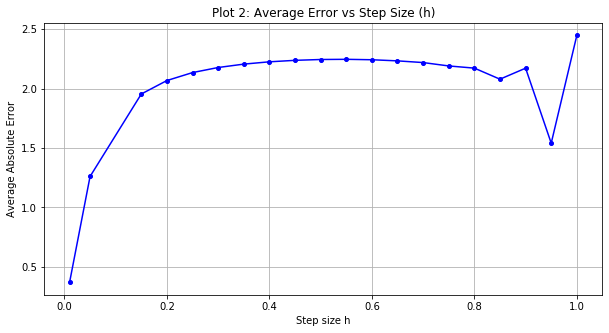

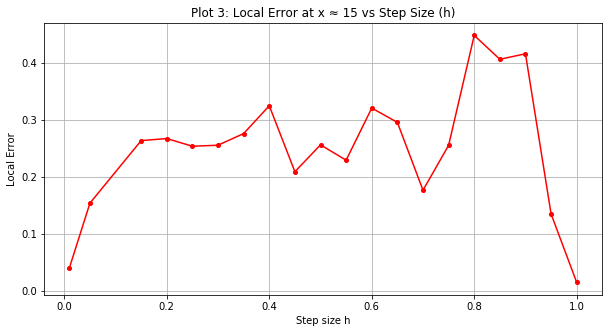

In [3]:
# 1. Define the ODE and the exact solution
def f(x, y):
    return -2 * y * np.cos(x)

def exact_sol(x):
   
    return np.exp(-2 * np.sin(x)) #y = e^(-2sin(x))

# 2. Define Euler's Method function
def euler(y_not, step, start, stop):
    # Determine the number of steps based on the range and step size
    num_steps = int(round((stop - start) / step))
    # Create the x and y arrays
    x = np.linspace(start, stop, num_steps + 1)
    y = np.zeros(num_steps + 1)
    
    y[0] = y_not # Initial condition
    
    # Iterative Euler loop
    for i in range(num_steps):
        y[i+1] = y[i] + step * f(x[i], y[i])
        
    return x, y

# 3. Parameters and Initialization
h_vals = [0.01, 0.05, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 
          0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00]
x_start, x_end = 0, 10 * np.pi
y0 = 1

avg_err = []
local_err_15 = []
all_runs = []

# 4. Execute Simulation
for h in h_vals:
    x, y = euler(y0, h, x_start, x_end)
    y_true = exact_sol(x)
    
    # Calculate Mean Absolute Error for the run
    avg_err.append(np.mean(np.abs(y - y_true)))
    
    # Find Local Error at x ≈ 15
    idx_15 = np.argmin(np.abs(x - 15.0))
    local_err_15.append(np.abs(y[idx_15] - y_true[idx_15]))
    
    all_runs.append((x, y, h))

# 5. Visualizations

# Plot 1: Euler's Method Approximation for all h
plt.figure(figsize=(12, 6))
for x, y, h in all_runs:
    plt.plot(x, y)
    
x_fine = np.linspace(x_start, x_end, 1000)
plt.plot(x_fine, exact_sol(x_fine), 'k--', linewidth=2, label="Exact Solution")
plt.title("Plot 1: Euler's Method Approximation for each value of h")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Average Error vs h
plt.figure(figsize=(10, 5))
plt.plot(h_vals, avg_err, 'bo-', linewidth=1.5, markersize=4)
plt.title("Plot 2: Average Error vs Step Size (h)")
plt.xlabel("Step size h")
plt.ylabel("Average Absolute Error")
plt.grid(True)
plt.show()

# Plot 3: Local Error at x ≈ 15 vs h
plt.figure(figsize=(10, 5))
plt.plot(h_vals, local_err_15, 'ro-', linewidth=1.5, markersize=4)
plt.title("Plot 3: Local Error at x ≈ 15 vs Step Size (h)")
plt.xlabel("Step size h")
plt.ylabel("Local Error")
plt.grid(True)
plt.show()